# 🚌 TransJakarta — Granularity Enrichment & Data Warehouse
**Paper:** Optimizing TransJakarta Fleet Allocation using Data Warehouse and Granularity Enrichment  
**Kelompok 15 — Bina Nusantara University**

---
### Alur Notebook ini:
1. Load data hasil cleansing Pentaho
2. Data cleaning lanjutan
3. Granularity Enrichment (tambah kolom temporal)
4. Build Fact Table + Dimension Tables (Star Schema)
5. Fleet Recommendation Algorithm
6. Analisis & Visualisasi
7. Export CSV → siap load ke PostgreSQL


## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")


✅ Libraries loaded successfully
   pandas  : 2.3.3
   numpy   : 2.3.5


In [2]:
# Load data RAW (bukan yang udah dicleaning)
df_raw = pd.read_csv("../../dfTransjakarta.csv")

print(f"Total rows: {len(df_raw)}")
print("\nJumlah null per kolom:")
print(df_raw.isnull().sum())
print("\nPersentase null:")
print((df_raw.isnull().sum() / len(df_raw) * 100).round(2))

Total rows: 37900

Jumlah null per kolom:
transID                0
payCardID              0
payCardBank            0
payCardName            0
payCardSex             0
payCardBirthDate       0
corridorID          1257
corridorName        1930
direction              0
tapInStops          1213
tapInStopsName         0
tapInStopsLat          0
tapInStopsLon          0
stopStartSeq           0
tapInTime              0
tapOutStops         2289
tapOutStopsName     1344
tapOutStopsLat      1344
tapOutStopsLon      1344
stopEndSeq          1344
tapOutTime          1344
payAmount           1007
dtype: int64

Persentase null:
transID             0.00
payCardID           0.00
payCardBank         0.00
payCardName         0.00
payCardSex          0.00
payCardBirthDate    0.00
corridorID          3.32
corridorName        5.09
direction           0.00
tapInStops          3.20
tapInStopsName      0.00
tapInStopsLat       0.00
tapInStopsLon       0.00
stopStartSeq        0.00
tapInTime           0.00
ta

## Cell 2 — Load Data Hasil Pentaho

In [3]:
df = pd.read_csv("../STEP1-PENTAHOO/Data_TransJakarta(Cleaned).csv", sep=";")

print(f"✅ Data loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"\nKolom yang tersedia:")
for col in df.columns:
    print(f"  - {col}")


✅ Data loaded: 36,556 rows × 13 columns

Kolom yang tersedia:
  - transID
  - corridorID
  - corridorName
  - tapInStops
  - tapInStopsName
  - tapInStopsLat
  - tapInStopsLon
  - tapInTime
  - tapOutStops
  - tapOutStopsName
  - tapOutStopsLat
  - tapOutStopsLon
  - tapOutTime


## Cell 3 — Preview & Cek Data Awal

In [4]:
# Lihat 5 baris pertama
print("=== 5 Baris Pertama ===")
display(df.head())

# Cek missing values
print("\n=== Missing Values per Kolom ===")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("✅ Tidak ada missing values!")
else:
    print(missing)

# Info tipe data
print("\n=== Tipe Data ===")
print(df.dtypes)


=== 5 Baris Pertama ===


,transID,corridorID,corridorName,tapInStops,tapInStopsName,tapInStopsLat,tapInStopsLon,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,tapOutTime
0,EIIW227B8L34VB,5,Matraman Baru - Ancol,P00142,Pal Putih,-6.184631,106.84402,4/3/2023 5:21,P00253,Tegalan,-6.203101,106.85715,4/3/2023 6:00
1,LGXO740D2N47GZ,6C,Stasiun Tebet - Karet via Patra Kuningan,B01963P,Kemenkes 2,-6.228700,106.83302,4/3/2023 5:42,B03307P,Sampoerna Strategic,-6.217152,106.81892,4/3/2023 6:40
2,DJWR385V2U57TO,R1A,Pantai Maju - Kota,B00499P,Gg. Kunir II,-6.133132,106.81435,4/3/2023 5:59,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,4/3/2023 6:50
3,JTUZ800U7C86EH,11D,Pulo Gebang - Pulo Gadung 2 via PIK,B05587P,Taman Elok 1,-6.195743,106.93526,4/3/2023 5:44,B03090P,Raya Penggilingan,-6.183068,106.93194,4/3/2023 6:28
4,VMLO535V7F95NJ,12,Tanjung Priok - Pluit,P00239,Sunter Boulevard Barat,-6.149650,106.88900,4/3/2023 6:17,P00098,Kali Besar Barat,-6.135355,106.81143,4/3/2023 6:57



=== Missing Values per Kolom ===
corridorID      1205
corridorName    1854
tapInStops      1177
tapOutStops      945
dtype: int64

=== Tipe Data ===
transID             object
corridorID          object
corridorName        object
tapInStops          object
tapInStopsName      object
tapInStopsLat      float64
tapInStopsLon      float64
tapInTime           object
tapOutStops         object
tapOutStopsName     object
tapOutStopsLat     float64
tapOutStopsLon     float64
tapOutTime          object
dtype: object


In [5]:
print(df.columns.tolist())
print(df.shape)

['transID', 'corridorID', 'corridorName', 'tapInStops', 'tapInStopsName', 'tapInStopsLat', 'tapInStopsLon', 'tapInTime', 'tapOutStops', 'tapOutStopsName', 'tapOutStopsLat', 'tapOutStopsLon', 'tapOutTime']
(36556, 13)


## Cell 4 — Data Cleaning Lanjutan
Pentaho sudah buang null di `tapInTime` & `tapOutTime`.  
Di sini kita beresin sisanya: koordinat kosong, corridorID kosong, dan format datetime.


In [6]:
rows_before = len(df)

# 1. Drop null di kolom penting
df.dropna(subset=[
    "tapInTime", "tapOutTime",
    "tapInStops", "tapInStopsName",
    "tapInStopsLat", "tapInStopsLon",
    "corridorID"
], inplace=True)

# 2. Parse datetime
df["tapInTime"]  = pd.to_datetime(df["tapInTime"],  format="%m/%d/%Y %H:%M", errors="coerce")
df["tapOutTime"] = pd.to_datetime(df["tapOutTime"], format="%m/%d/%Y %H:%M", errors="coerce")
df.dropna(subset=["tapInTime", "tapOutTime"], inplace=True)

# 3. Hitung durasi perjalanan, buang yang negatif/nol
df["trip_duration_min"] = (df["tapOutTime"] - df["tapInTime"]).dt.total_seconds() / 60
df = df[df["trip_duration_min"] > 0].copy()

rows_after = len(df)
print(f"✅ Cleaning selesai")
print(f"   Rows sebelum : {rows_before:,}")
print(f"   Rows sesudah : {rows_after:,}")
print(f"   Dibuang      : {rows_before - rows_after:,} rows")


✅ Cleaning selesai
   Rows sebelum : 36,556
   Rows sesudah : 17,722
   Dibuang      : 18,834 rows


## Cell 5 — Granularity Enrichment ⭐
Ini inti dari paper kita: memecah data harian menjadi granularitas per-jam  
dan menambahkan label temporal (peak period, day of week, dsb).


In [7]:
# Ekstrak komponen temporal dari tapInTime
df["date"]        = df["tapInTime"].dt.date
df["hour"]        = df["tapInTime"].dt.hour
df["day_of_week"] = df["tapInTime"].dt.day_name()
df["is_weekend"]  = df["tapInTime"].dt.dayofweek >= 5

# Klasifikasi Peak Period
def classify_peak(hour):
    if 6 <= hour <= 9:
        return "Morning Peak"
    elif 16 <= hour <= 19:
        return "Evening Peak"
    elif 11 <= hour <= 13:
        return "Midday"
    elif hour >= 22 or hour <= 5:
        return "Off-Peak Night"
    else:
        return "Off-Peak"

df["peak_period"] = df["hour"].apply(classify_peak)

print("✅ Granularity enrichment selesai!")
print("\nKolom baru yang ditambahkan:")
new_cols = ["date", "hour", "day_of_week", "is_weekend", "peak_period", "trip_duration_min"]
print(df[new_cols].head(10).to_string())

print("\n=== Distribusi Peak Period ===")
print(df["peak_period"].value_counts())


✅ Granularity enrichment selesai!

Kolom baru yang ditambahkan:
          date  hour day_of_week  is_weekend     peak_period  trip_duration_min
0   2023-04-03     5      Monday       False  Off-Peak Night               39.0
1   2023-04-03     5      Monday       False  Off-Peak Night               58.0
2   2023-04-03     5      Monday       False  Off-Peak Night               51.0
3   2023-04-03     5      Monday       False  Off-Peak Night               44.0
4   2023-04-03     6      Monday       False    Morning Peak               40.0
5   2023-04-03     5      Monday       False  Off-Peak Night               44.0
7   2023-04-03     6      Monday       False    Morning Peak               50.0
8   2023-04-03     5      Monday       False  Off-Peak Night               54.0
9   2023-04-03     6      Monday       False    Morning Peak               51.0
10  2023-04-03     6      Monday       False    Morning Peak               28.0

=== Distribusi Peak Period ===
peak_period
Morning Peak

## Cell 6 — Build Fact Table: `fact_passenger_flow`
Agregasi penumpang per **stasiun per jam** — ini yang jadi inti data warehouse kita.


In [8]:
fact_passenger_flow = (
    df.groupby([
        "tapInStops", "tapInStopsName",
        "tapInStopsLat", "tapInStopsLon",
        "corridorID", "corridorName",
        "date", "hour", "peak_period"
    ])
    .size()
    .reset_index(name="passenger_count")
)

print(f"✅ Fact table dibuat: {len(fact_passenger_flow):,} rows")
print("\nPreview:")
display(fact_passenger_flow.head(10))


✅ Fact table dibuat: 17,089 rows

Preview:


,tapInStops,tapInStopsName,tapInStopsLat,tapInStopsLon,corridorID,corridorName,date,hour,peak_period,passenger_count
0,B00001P,18 Office Park,-6.299146,106.8321,JAK.46,Pasar Minggu - Jagakarsa,2023-04-04,5,Off-Peak Night,1
1,B00001P,18 Office Park,-6.299146,106.8321,JAK.46,Pasar Minggu - Jagakarsa,2023-04-05,6,Morning Peak,1
2,B00001P,18 Office Park,-6.299146,106.8321,JAK.46,Pasar Minggu - Jagakarsa,2023-04-06,6,Morning Peak,1
3,B00001P,18 Office Park,-6.299146,106.8321,JAK.46,Pasar Minggu - Jagakarsa,2023-04-07,6,Morning Peak,1
4,B00001P,18 Office Park,-6.299146,106.8321,JAK.46,Pasar Minggu - Jagakarsa,2023-04-10,6,Morning Peak,1
5,B00001P,18 Office Park,-6.299146,106.8321,JAK.46,Pasar Minggu - Jagakarsa,2023-04-11,6,Morning Peak,1
6,B00001P,18 Office Park,-6.299146,106.8321,JAK.46,Pasar Minggu - Jagakarsa,2023-04-13,6,Morning Peak,1
7,B00001P,18 Office Park,-6.299146,106.8321,JAK.46,Pasar Minggu - Jagakarsa,2023-04-14,6,Morning Peak,1
8,B00001P,18 Office Park,-6.299146,106.8321,JAK.46,Pasar Minggu - Jagakarsa,2023-04-17,6,Morning Peak,1
9,B00001P,18 Office Park,-6.299146,106.8321,JAK.46,Pasar Minggu - Jagakarsa,2023-04-18,6,Morning Peak,1


## Cell 7 — Fleet Recommendation Algorithm 🚌
Formula menghitung jumlah bus yang dibutuhkan per stasiun per jam.

**Asumsi:**
- Kapasitas bus: 60 penumpang
- Headway (interval kedatangan): 10 menit → 6 bus/jam
- Load factor target: 80%
- Multiplier berbeda untuk tiap peak period


In [ ]:
BUS_CAPACITY    = 60    # penumpang per bus
HEADWAY_MINUTES = 10    # interval kedatangan (menit)
EFFICIENCY      = 0.80  # load factor target

def estimate_bus_demand(passenger_count, peak_period):
    buses_per_hour     = 60 / HEADWAY_MINUTES        # = 6 bus/jam
    capacity_per_hour  = buses_per_hour * BUS_CAPACITY * EFFICIENCY  # = 288
    raw_demand         = np.ceil(passenger_count / capacity_per_hour)

    multipliers = {
        "Morning Peak"  : 1.3,
        "Evening Peak"  : 1.3,
        "Midday"        : 1.1,
        "Off-Peak"      : 0.8,
        "Off-Peak Night": 0.5
    }
    multiplier = multipliers.get(peak_period, 1.0)
    return max(1, int(np.ceil(raw_demand * multiplier)))

fact_passenger_flow["estimated_bus_demand"] = fact_passenger_flow.apply(
    lambda row: estimate_bus_demand(row["passenger_count"], row["peak_period"]), axis=1
)

# Flag overloaded: stasiun dengan penumpang >= 50 dalam 1 jam
OVERLOAD_THRESHOLD = 3
fact_passenger_flow["is_overloaded"] = fact_passenger_flow["passenger_count"] >= OVERLOAD_THRESHOLD

print("✅ Fleet recommendation selesai!")
print("\nDistribusi estimated_bus_demand:")
print(fact_passenger_flow["estimated_bus_demand"].value_counts().sort_index())
print(f"\nJumlah slot overloaded: {fact_passenger_flow['is_overloaded'].sum()}")


✅ Fleet recommendation selesai!

Distribusi estimated_bus_demand:
estimated_bus_demand
1     3979
2    13110
Name: count, dtype: int64

Jumlah slot overloaded: 0


## Cell 8 — Build Dimension Tables (Star Schema)
Sesuai paper: `dim_station`, `dim_time`, `dim_route`


In [10]:
# ── Dim_Station ──────────────────────────────────────
dim_station = (
    df[["tapInStops", "tapInStopsName", "tapInStopsLat", "tapInStopsLon"]]
    .drop_duplicates()
    .rename(columns={
        "tapInStops"    : "station_id",
        "tapInStopsName": "station_name",
        "tapInStopsLat" : "latitude",
        "tapInStopsLon" : "longitude"
    })
    .reset_index(drop=True)
)
dim_station.insert(0, "station_key", range(1, len(dim_station) + 1))

# ── Dim_Time ──────────────────────────────────────────
dim_time = (
    fact_passenger_flow[["date", "hour", "peak_period"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_time.insert(0, "time_id", range(1, len(dim_time) + 1))
dim_time["day_of_week"] = pd.to_datetime(dim_time["date"]).dt.day_name()
dim_time["is_weekend"]  = pd.to_datetime(dim_time["date"]).dt.dayofweek >= 5

# ── Dim_Route ─────────────────────────────────────────
dim_route = (
    df[["corridorID", "corridorName"]]
    .drop_duplicates()
    .rename(columns={"corridorID": "route_id", "corridorName": "route_name"})
    .reset_index(drop=True)
)
dim_route.insert(0, "route_key", range(1, len(dim_route) + 1))

print("✅ Dimension tables dibuat!")
print(f"   dim_station : {len(dim_station):>5,} rows")
print(f"   dim_time    : {len(dim_time):>5,} rows")
print(f"   dim_route   : {len(dim_route):>5,} rows")
print(f"   fact table  : {len(fact_passenger_flow):>5,} rows")

print("\n=== dim_station preview ===")
display(dim_station.head())
print("\n=== dim_time preview ===")
display(dim_time.head())
print("\n=== dim_route preview ===")
display(dim_route.head())


✅ Dimension tables dibuat!
   dim_station : 1,844 rows
   dim_time    :   221 rows
   dim_route   :   385 rows
   fact table  : 17,089 rows

=== dim_station preview ===


,station_key,station_id,station_name,latitude,longitude
0,1,P00142,Pal Putih,-6.184631,106.84402
1,2,B01963P,Kemenkes 2,-6.228700,106.83302
2,3,B00499P,Gg. Kunir II,-6.133132,106.81435
3,4,B05587P,Taman Elok 1,-6.195743,106.93526
4,5,P00239,Sunter Boulevard Barat,-6.149650,106.88900



=== dim_time preview ===


,time_id,date,hour,peak_period,day_of_week,is_weekend
0,1,2023-04-04,5,Off-Peak Night,Tuesday,False
1,2,2023-04-05,6,Morning Peak,Wednesday,False
2,3,2023-04-06,6,Morning Peak,Thursday,False
3,4,2023-04-07,6,Morning Peak,Friday,False
4,5,2023-04-10,6,Morning Peak,Monday,False



=== dim_route preview ===


,route_key,route_id,route_name
0,1,5,Matraman Baru - Ancol
1,2,6C,Stasiun Tebet - Karet via Patra Kuningan
2,3,R1A,Pantai Maju - Kota
3,4,11D,Pulo Gebang - Pulo Gadung 2 via PIK
4,5,12,Tanjung Priok - Pluit


## Cell 9 — Analisis: Peak Hour & Top Stations

In [11]:
# ── Peak Hour Analysis ───────────────────────────────
print("=== TOTAL PENUMPANG PER JAM ===")
peak_summary = (
    fact_passenger_flow.groupby(["hour", "peak_period"])["passenger_count"]
    .sum()
    .reset_index()
    .sort_values("passenger_count", ascending=False)
)
display(peak_summary.head(12))

# ── Top 10 Busiest Stations ───────────────────────────
print("\n=== TOP 10 STASIUN TERSIBUK ===")
station_summary = (
    fact_passenger_flow.groupby("tapInStopsName")["passenger_count"]
    .sum()
    .reset_index()
    .rename(columns={"tapInStopsName": "station_name"})
    .sort_values("passenger_count", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
station_summary.index += 1
display(station_summary)

# ── Fleet Demand per Corridor ─────────────────────────
print("\n=== BUS DEMAND PER KORIDOR (TOP 10) ===")
corridor_demand = (
    fact_passenger_flow.groupby("corridorID")
    .agg(total_passengers=("passenger_count", "sum"),
         max_bus_demand=("estimated_bus_demand", "max"))
    .reset_index()
    .sort_values("max_bus_demand", ascending=False)
    .head(10)
)
display(corridor_demand)


=== TOTAL PENUMPANG PER JAM ===


,hour,peak_period,passenger_count
1,6,Morning Peak,5137
0,5,Off-Peak Night,2964
2,7,Morning Peak,2454
3,8,Morning Peak,1933
12,17,Evening Peak,1196
4,9,Morning Peak,809
11,16,Evening Peak,694
14,19,Evening Peak,488
16,21,Off-Peak,479
13,18,Evening Peak,478



=== TOP 10 STASIUN TERSIBUK ===


,station_name,passenger_count
1,Garuda Taman Mini,117
2,Penjaringan,92
3,Rusun Kapuk Muara,83
4,BNN LRT,75
5,BKN,73
6,Penggilingan,70
7,Rawa Selatan,70
8,Tendean,67
9,Petojo,62
10,Tirtayasa,61



=== BUS DEMAND PER KORIDOR (TOP 10) ===


,corridorID,total_passengers,max_bus_demand
0,1,116,2
152,JAK.31,61,2
141,JAK.20,76,2
142,JAK.21,64,2
143,JAK.22,68,2
144,JAK.23,70,2
145,JAK.24,39,2
146,JAK.25,47,2
147,JAK.26,113,2
148,JAK.27,122,2


## Cell 10 — Visualisasi (Preview sebelum Power BI)

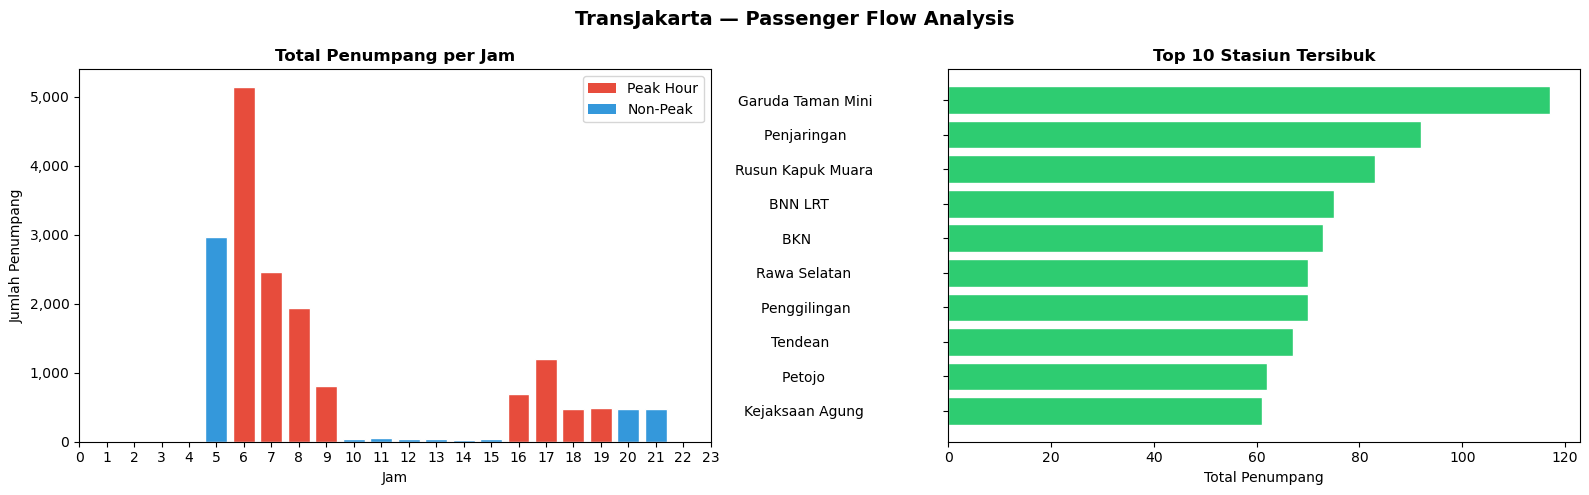

✅ Chart disimpan sebagai transjakarta_analysis.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("TransJakarta — Passenger Flow Analysis", fontsize=14, fontweight="bold")

# ── Chart 1: Penumpang per Jam ────────────────────────
hourly = (
    fact_passenger_flow.groupby("hour")["passenger_count"]
    .sum()
    .reset_index()
    .sort_values("hour")
)
colors = ["#e74c3c" if h in range(6,10) or h in range(16,20) else "#3498db"
          for h in hourly["hour"]]
axes[0].bar(hourly["hour"], hourly["passenger_count"], color=colors, edgecolor="white")
axes[0].set_title("Total Penumpang per Jam", fontweight="bold")
axes[0].set_xlabel("Jam")
axes[0].set_ylabel("Jumlah Penumpang")
axes[0].set_xticks(range(0, 24))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e74c3c", label="Peak Hour"),
                   Patch(facecolor="#3498db", label="Non-Peak")]
axes[0].legend(handles=legend_elements)

# ── Chart 2: Top 10 Stasiun ───────────────────────────
top10 = (
    fact_passenger_flow.groupby("tapInStopsName")["passenger_count"]
    .sum()
    .nlargest(10)
    .sort_values()
)
axes[1].barh(top10.index, top10.values, color="#2ecc71", edgecolor="white")
axes[1].set_title("Top 10 Stasiun Tersibuk", fontweight="bold")
axes[1].set_xlabel("Total Penumpang")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("transjakarta_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart disimpan sebagai transjakarta_analysis.png")


## Cell 11 — Export ke CSV
Output 4 file CSV yang siap diimport ke PostgreSQL.


In [13]:
import os

# Ganti OUTPUT_DIR sesuai folder yang lo mau
OUTPUT_DIR = "."   # folder yang sama dengan notebook
# OUTPUT_DIR = r"C:\Users\NamaUser\Documents\TransJakarta\output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

fact_passenger_flow.to_csv(f"{OUTPUT_DIR}/fact_passenger_flow.csv", index=False)
dim_station.to_csv(f"{OUTPUT_DIR}/dim_station.csv", index=False)
dim_time.to_csv(f"{OUTPUT_DIR}/dim_time.csv", index=False)
dim_route.to_csv(f"{OUTPUT_DIR}/dim_route.csv", index=False)

print("✅ Export selesai! File yang dihasilkan:")
print(f"   📄 fact_passenger_flow.csv  → {len(fact_passenger_flow):,} rows")
print(f"   📄 dim_station.csv          → {len(dim_station):,} rows")
print(f"   📄 dim_time.csv             → {len(dim_time):,} rows")
print(f"   📄 dim_route.csv            → {len(dim_route):,} rows")
print(f"\n📁 Lokasi: {os.path.abspath(OUTPUT_DIR)}")
print("\n➡️  Langkah selanjutnya: import file-file ini ke PostgreSQL")


✅ Export selesai! File yang dihasilkan:
   📄 fact_passenger_flow.csv  → 17,089 rows
   📄 dim_station.csv          → 1,844 rows
   📄 dim_time.csv             → 221 rows
   📄 dim_route.csv            → 385 rows

📁 Lokasi: d:\ABIMANYU\BINUS\SEM 4\Data Engineering\PROJECT_DE\STEP2-PYTHON

➡️  Langkah selanjutnya: import file-file ini ke PostgreSQL


## ✅ Selesai!

### Summary yang udah dikerjain:
| Step | Keterangan | Status |
|------|-----------|--------|
| Load Data | Baca CSV hasil Pentaho | ✅ |
| Data Cleaning | Buang null, fix datetime, filter durasi negatif | ✅ |
| Granularity Enrichment | Tambah hour, peak_period, day_of_week, is_weekend | ✅ |
| Fact Table | `fact_passenger_flow` dengan passenger_count per stasiun per jam | ✅ |
| Fleet Algorithm | `estimated_bus_demand` + `is_overloaded` flag | ✅ |
| Dimension Tables | `dim_station`, `dim_time`, `dim_route` | ✅ |
| Export CSV | 4 file siap diimport ke PostgreSQL | ✅ |

### Langkah Selanjutnya:
1. **PostgreSQL** — jalankan `create_schema.sql`, lalu import 4 CSV ini
2. **Power BI** — connect ke PostgreSQL, buat geospatial map + dashboard fleet
